### Building a recommendation system
The flow graph isn't truly bipartite — most transactions are both senders and
  receivers, so U and V embeddings would collapse. You'd need to either:
  1. Treat sender/receiver as two separate roles (two embedding tables, same
  nodes)
  2. Use a single embedding per transaction and model interactions as inner
  products

  Option 2 is essentially LightGCN — which is a GNN but derived from MF
  thinking.

  The cleanest pure MF formulation:

  V_flow ≈ U_sender × U_receiver^T    (adjacency reconstruction)

  + supervised head:
  class_i = sigmoid(w^T · U_i)        (predict label from embedding)

  Loss = α · ||V_flow - U U^T||²  +  β · BCE(y_known, ŷ_known)

  Train on known labels (class 0/1), predict for class 2. This is
  semi-supervised CF with graph structure as the interaction signal.
  Joint loss:
    L = α · L_link  +  β · L_class

    L_link  = BCE(A[i,j], σ(uᵢ · uⱼ))   — adjacency reconstruction (CF signal)
    L_class = BCE(yᵢ,     σ(w^T uᵢ))     — label prediction (supervised signal)

  ### Two variants
    Option 1 — Two roles: U_sender, U_receiver (separate tables, same nodes)
                handles directed graph naturally; combined embedding = (U_s + U_r)/2
    Option 2 — Single embedding U: symmetric, simpler, equivalent to LightGCN-0
                U_sender = U_receiver = U

  ### Split
    Train supervision: class 0/1 labels from t ≤ 35
    Val:  t = 36..40
    Test: t = 41..49  (predict class for all, evaluate on class 0/1 only)



## Semi-Supervised CF via Matrix Factorization

This is the first model that uses known labels (class 0/1) as explicit ratings — the true CF formulation:

    - "Users"   = transactions
    - "Items"   = transactions (same entity, interaction = flow)
    - "Ratings" = class label (0=licit, 1=illicit) — sparse, ~15% known
    - "Missing" = class 2 (unknown) — to be predicted

The flow graph provides the interaction structure for embedding learning.
  Class labels provide supervision for the prediction head.


# Imports

In [28]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline

from sklearn.decomposition import  TruncatedSVD, PCA
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import f1_score, precision_score, accuracy_score, recall_score
from sklearn.linear_model import LogisticRegression                                       

from scipy.sparse import csr_matrix                                                       


# Data loading

In [2]:
datafolder = './data'
data = os.path.join(datafolder, "1", "elliptic_bitcoin_dataset","elliptic_txs_features.csv")

datafolder = os.path.join(datafolder, "1","elliptic_bitcoin_dataset")   


There are 166 features to the dataset, 92 local and 74 aggregated. [add source - demistifying... ]
The CSV does not have the columns defined
txid - transaction id
time_step - 1-49 timestamps groups
lf_{number} - local feature number 1-92
af_{number} - aggregated feature number 1-74


In [3]:
cols = ['txId','time_step']


local_cols = [f'lf_{i+1}' for i in range(93)]
agg_cols = [f'af_{i+1}' for i in range(72)]

cols += local_cols + agg_cols

In [8]:
feature_cols = local_cols + agg_cols

In [4]:
features = pd.read_csv(os.path.join(datafolder, "elliptic_txs_features.csv"),  index_col=False, names=cols,)
edges = pd.read_csv(os.path.join(datafolder, "elliptic_txs_edgelist.csv"))
classes = pd.read_csv(os.path.join(datafolder, "elliptic_txs_classes.csv"))


In [12]:
# map classes: licit - 0; illicit- 1;  unknown -2
class_mapping = {'2': 0, '1': 1, 'unknown': 2}
classes.replace({"class": class_mapping}, inplace=True).astype(int)
classes['class'].value_counts()

class
2    157205
0     42019
1      4545
Name: count, dtype: int64

In [7]:
df = pd.merge(features, classes, on='txId')

# implementation with SKLEARN: TSVD

Step 1: TruncatedSVD on the sparse adjacency matrix → node embeddings (captures graph     
  structure)                                                                                
  Step 2: LogisticRegression on known labels using those embeddings → predicts unknown      
  classes  

## Pipeline Definition

In [ ]:
def build_adjacency(df, edges, symmetric=True):
    # the adj. represents the links between the transactions. each transaction is both a sender and receiver.
    node_to_idx = {nid: i for i, nid in enumerate(df['txId'].values)}
    n = len(node_to_idx)
    mask = edges['txId1'].isin(node_to_idx) & edges['txId2'].isin(node_to_idx)            
    rel  = edges[mask]
    src  = rel['txId1'].map(node_to_idx).values
    dst  = rel['txId2'].map(node_to_idx).values
    data = np.ones(len(src))
    A    = csr_matrix((data, (src, dst)), shape=(n, n))     # csr to compress the sparse data
    if symmetric:
        A = A + A.T         # undirected — single embedding
    return A, node_to_idx

  

In [39]:
def mf_cf_sklearn(df, edges, feature_cols,
                    train_ts=range(1,36), val_ts=range(36,41),
                    test_ts=range(41,50), k=32,
                    use_features=True):

    node_to_idx = {nid: i for i, nid in enumerate(df['txId'].values)}

    # Step 1: graph embeddings via SVD of adjacency
    A, node_to_idx = build_adjacency(df, edges, symmetric=True)
    svd = TruncatedSVD(n_components=k, random_state=90)
    G   = svd.fit_transform(A)      # (n_nodes × k) — graph embedding

    # Step 2: node features (optional)
    X = df[feature_cols].values.astype(np.float32)
    train_mask = (df['class'] == 0) & (df['time_step'].isin(train_ts))
    feat_scaler = RobustScaler().fit(X[train_mask.values])
    X_s = feat_scaler.transform(X)

    # combine graph embedding + node features
    if use_features:
        emb = np.hstack([G, X_s])
    else:
        emb = G
    # Step 3: train logistic regression on known labels
    labeled_mask = (df['class'] < 2) & (df['time_step'].isin(train_ts))
    X_labeled = emb[labeled_mask.values]
    y_labeled = df.loc[labeled_mask, 'class'].values.astype(int)
                
    clf = LogisticRegression(max_iter=10000, solver='lbfgs', random_state=90)
    clf.fit(X_labeled, y_labeled) 
    
    def evaluate(ts, label):
        mask    = df['time_step'].isin(ts) & (df['class'] < 2)
        X_eval  = emb[mask.values]
        y_eval  = df.loc[mask, 'class'].values.astype(float)
        scores  = clf.predict_proba(X_eval)[:, 1].astype(float)
        preds  = clf.predict(X_eval)

        auc = roc_auc_score(y_eval, scores)                                                   
        ap  = average_precision_score(y_eval, scores)                                         
        f1  = f1_score(y_eval, preds)                                                         
        pre = precision_score(y_eval, preds)                                                  
        recall = recall_score(y_eval, preds)                                                  
        acc = accuracy_score(y_eval, preds)                                                   
                                                                                            
        print(f'{label} — ROC-AUC: {auc:.4f} | AP: {ap:.4f} | 'f'F1: {f1:.4f} | Precision: {pre:.4f} | Recall: {recall:.4f} | Accuracy: {acc:.4f}')                   
        return scores, y_eval
        

    val_scores,  val_y  = evaluate(val_ts,  'Val ')
    test_scores, test_y = evaluate(test_ts, 'Test')
    return clf, svd, emb, val_scores, test_scores

In [42]:
clf, svd, emb, val_scores, test_scores = mf_cf_sklearn(
      df, edges, feature_cols,  
      train_ts=range(1,36), val_ts=range(36,41), test_ts=range(41,50),                      
      k=64, use_features=True
  ) 

/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 6365 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Val  — ROC-AUC: 0.9446 | AP: 0.6618 | F1: 0.5668 | Precision: 0.4410 | Recall: 0.7931 | Accuracy: 0.9147
Test — ROC-AUC: 0.8468 | AP: 0.2938 | F1: 0.3373 | Precision: 0.2350 | Recall: 0.5973 | Accuracy: 0.8767


In [51]:
def plot_embeddings(emb, df, sample_n=5000):

    labeled = df['class'] < 2
    emb_lab = emb[labeled.values]
    y_lab   = df.loc[labeled, 'class'].values

    # sample for readability
    idx = np.random.choice(len(emb_lab), min(sample_n, len(emb_lab)), replace=False)

    pca    = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb_lab[idx])

    fig, ax = plt.subplots(figsize=(8, 6))
    colors  = {0: 'steelblue', 1: 'crimson'}
    for cls, label in [(0, 'Licit'), (1, 'Illicit')]:
        mask = y_lab[idx] == cls
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=colors[cls], alpha=0.4, s=5, label=label)

    ax.set_title(f'Node embeddings — PCA 2D\n'
                f'(explained variance: {pca.explained_variance_ratio_.sum():.2%})')
    ax.legend()
   # ax.set_xlim(left=None, right=np.percentile(emb_2d[:, 0], 75)) 
    plt.tight_layout()
    plt.show()



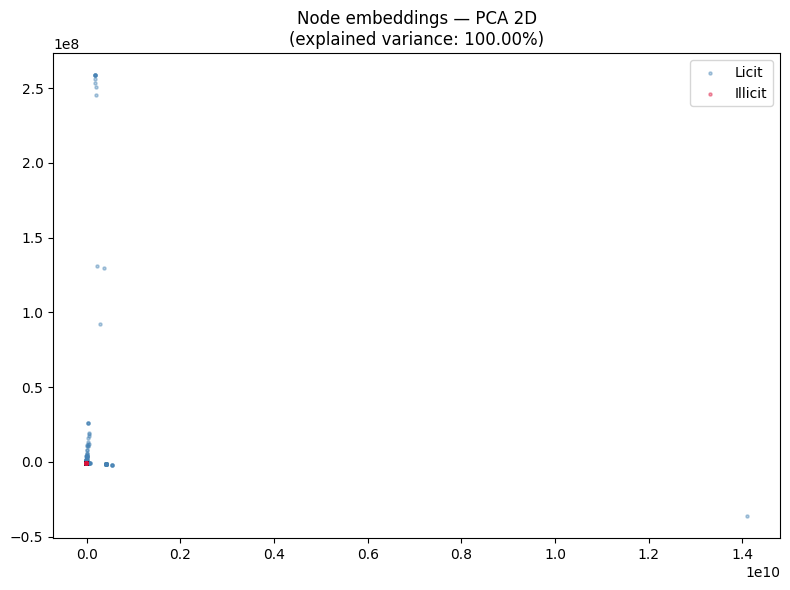

In [52]:
plot_embeddings(emb, df)


## single vs. double table

**Variant 1 ( symmetric - also above with TSVD):**
`TruncatedSVD` on `A + Aᵀ` collapses the directed graph into undirected before
factorization. Each transaction gets *one* embedding that mixes both its sender and
receiver behavior. Directionality is lost.

**Variant 2 (two-role — directed):**
The Bitcoin flow graph is inherently directed — money flows one way. We factorize the
directed adjacency `A` via SVD:

    A ≈ U Σ Vᵀ

- `U_sender` — left singular vectors: how this node behaves *as a sender*
- `V_receiver` — right singular vectors: how this node behaves *as a receiver*

Both are concatenated per node: `emb_i = [U_i ‖ V_i]` → 2k dimensions.

This lets the classifier distinguish nodes that are pure senders vs. pure receivers vs.
balanced — a potential fraud signal that symmetrizing destroys.

### PyTorch Joint MF: Double-Table and Single-Table

  Both variants share the same architecture and training loop.
  The only difference is whether sender and receiver embeddings are the same table.

  **Double-table** (`shared_table=False`):
      E_sender  (n × k) — how this node behaves as sender
      E_receiver (n × k) — how this node behaves as receiver
      Link score: σ(E_sender[i] · E_receiver[j])
      Classifier input: [E_sender_i ‖ E_receiver_i ‖ features]

  **Single-table** (`shared_table=True`):
      E (n × k) — one embedding, E_sender = E_receiver = E
      Equivalent to symmetric MF / LightGCN-0

  Joint loss:
      L = α · L_link  +  β · L_class
      L_link  = BCE on positive edges + sampled negatives
      L_class = BCE on known labels (class 0/1 from train timesteps)


In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class MF_CF(nn.Module):
    def __init__(self, n_nodes, n_features, k=32, shared_table=False, hidden_dim=64):
        super().__init__()
        self.E_sender = nn.Embedding(n_nodes, k)
        self.E_receiver = self.E_sender if shared_table else nn.Embedding(n_nodes, k)

        self.classifier = nn.Sequential(
            nn.Linear(2 * k + n_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        nn.init.xavier_uniform_(self.E_sender.weight)   # values from X.uniform distribution to initialize weights - so the variance doesnt cause vanishing/exploding gradients
        
        if not shared_table:
            self.E_receiver = nn.Embedding(n_nodes, k)      # create separate if not shared
            nn.init.xavier_uniform_(self.E_receiver.weight)
        else:
            self.E_receiver = self.E_sender

    def link_score(self, src, dst):
        return (self.E_sender(src) * self.E_receiver(dst)).sum(dim=1)       # @ scalar is the raw link score - compatibility of se_i and re_j.("immitates connections") 

    def classify(self, node_ids, features):
        e_s = self.E_sender(node_ids)
        e_r = self.E_receiver(node_ids)
        return self.classifier(torch.cat([e_s, e_r, features], dim=1)).squeeze(1)


In [ ]:
def sample_negatives(n_nodes, n_pos, device):         # n_nodes = nr of Edges.
      """
      randomly sampled node pairs with no edge between them. The model should score these LOW (label= 0).
      """
      return (torch.randint(0, n_nodes, (n_pos,), device=device),
              torch.randint(0, n_nodes, (n_pos,), device=device))

The contrast between real and fake edges is what forces the embeddings to encode graph structure.
pos_scores  → real edges    → target 1
neg_scores  → random pairs  → target 0                                                                           
   
Both are concatenated and fed into one BCE loss

Training: 
① Link loss — learn the graph structure
     - Score all real training edges (should be high)                                                              
     - Sample same number of random fake edges (should be low)                                                     
     - BCE pushes real edges → 1, fake edges → 0                                                                   
     - This trains E_sender and E_receiver to encode who-connects-to-whom                                          
                                                                                                                   
  ② Classification loss — learn to detect fraud                                                                    
     - Take all labeled nodes (class 0/1) from training timesteps                                                  
     - Concatenate [E_sender ‖ E_receiver ‖ features] → classifier head → sigmoid                                  
     - BCE against true labels                                                                                     
     - This trains the classifier + nudges embeddings toward fraud-separable space                                 
                                                                                                                   
  ③ Combined loss = α · L_link + β · L_class
     - Both gradients flow back simultaneously                                                                     
     - α and β control the trade-off — equal weight (1.0/1.0) to start                                             
                                                                                                                   
  The key insight: ① and ② pull the embeddings in the same direction — nodes that are structurally similar         
  (connected) should have similar embeddings, and fraud nodes have a distinct connection pattern. The joint loss   
  exploits both signals at once.

In [63]:
def train_mf_cf(model, optimizer, src, dst,
                  labeled_idx, labeled_feats, labeled_y,
                  alpha=1.0, beta=1.0, n_epochs=200, device='cpu'):
      model.train()
      for epoch in range(n_epochs):
          optimizer.zero_grad()

          # link loss: positive edges + random negatives
          pos_scores = model.link_score(src, dst)       # Edges thatexist in the training graph
          neg_src, neg_dst = sample_negatives(model.E_sender.num_embeddings, len(src), device)
          neg_scores = model.link_score(neg_src, neg_dst)

          link_scores  = torch.cat([pos_scores, neg_scores])
          link_targets = torch.cat([torch.ones(len(src), device=device),
                                    torch.zeros(len(src), device=device)])
          L_link = F.binary_cross_entropy_with_logits(link_scores, link_targets)

          # classification loss on known labels
          L_class = F.binary_cross_entropy_with_logits(
              model.classify(labeled_idx, labeled_feats), labeled_y)

          loss = alpha * L_link + beta * L_class
          loss.backward()
          optimizer.step()

          if (epoch + 1) % 20 == 0:
              print(f'  Epoch {epoch+1:>3}: loss={loss.item():.4f} '
                    f'(link={L_link.item():.4f}, class={L_class.item():.4f})')

In [57]:
@torch.no_grad()
def evaluate_mf_cf(model, df, node_to_idx, X_s, eval_ts, label, device='cpu'):
    model.eval()
    mask = df['time_step'].isin(eval_ts) & (df['class'] < 2)
    eval_df = df[mask]

    idx = torch.tensor([node_to_idx[n] for n in eval_df['txId'].values],
                dtype=torch.long, device=device)
    feats = torch.tensor(X_s[mask.values], dtype=torch.float32, device=device)
    y = eval_df['class'].values.astype(int)

    scores = torch.sigmoid(model.classify(idx, feats)).cpu().numpy()
    preds  = (scores > 0.5).astype(int)

    auc = roc_auc_score(y, scores)
    ap  = average_precision_score(y, scores)
    f1  = f1_score(y, preds)
    pre = precision_score(y, preds)
    rec = recall_score(y, preds)
    acc = accuracy_score(y, preds)

    print(f'{label} — ROC-AUC: {auc:.4f} | AP: {ap:.4f} | F1: {f1:.4f} | '
        f'Precision: {pre:.4f} | Recall: {rec:.4f} | Accuracy: {acc:.4f}')
    return scores, y

In [58]:
def mf_cf_torch(df, edges, feature_cols,
                  train_ts=range(1, 36), val_ts=range(36, 41), test_ts=range(41, 50),
                  k=32, shared_table=False, hidden_dim=64,
                  alpha=1.0, beta=1.0, n_epochs=200, lr=1e-3):

      device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
      node_to_idx = {nid: i for i, nid in enumerate(df['txId'].values)}
      n_nodes = len(node_to_idx)

      # edges restricted to training timesteps
      train_txids = set(df[df['time_step'].isin(train_ts)]['txId'].values)
      train_edges = edges[edges['txId1'].isin(train_txids) & edges['txId2'].isin(train_txids)]
      src = torch.tensor([node_to_idx[x] for x in train_edges['txId1'].values],
                         dtype=torch.long, device=device)
      dst = torch.tensor([node_to_idx[x] for x in train_edges['txId2'].values],
                         dtype=torch.long, device=device)

      # node features — fit scaler on licit train nodes only
      X = df[feature_cols].values.astype(np.float32)
      licit_train = (df['class'] == 0) & (df['time_step'].isin(train_ts))
      X_s = RobustScaler().fit(X[licit_train.values]).transform(X)
      n_features = X_s.shape[1]

      # labeled nodes for classification loss
      labeled_mask = (df['class'] < 2) & (df['time_step'].isin(train_ts))
      labeled_df   = df[labeled_mask]
      labeled_idx  = torch.tensor([node_to_idx[n] for n in labeled_df['txId'].values],
                                  dtype=torch.long, device=device)
      labeled_feats = torch.tensor(X_s[labeled_mask.values], dtype=torch.float32, device=device)
      labeled_y     = torch.tensor(labeled_df['class'].values.astype(np.float32), device=device)

      model     = MF_CF(n_nodes, n_features, k=k, shared_table=shared_table,
                        hidden_dim=hidden_dim).to(device)
      optimizer = torch.optim.Adam(model.parameters(), lr=lr)

      label_str = 'single-table' if shared_table else 'double-table'
      print(f'--- {label_str} (k={k}) ---')
      train_mf_cf(model, optimizer, src, dst, labeled_idx, labeled_feats, labeled_y,
                  alpha=alpha, beta=beta, n_epochs=n_epochs, device=device)

      val_scores,  val_y  = evaluate_mf_cf(model, df, node_to_idx, X_s, val_ts,  'Val ', device)
      test_scores, test_y = evaluate_mf_cf(model, df, node_to_idx, X_s, test_ts, 'Test', device)
      return model, val_scores, test_scores


In [65]:
feature_cols = local_cols + agg_cols

model_dt, val_s, test_s = mf_cf_torch(
    df, edges, feature_cols,
    k=128, shared_table=False,
    alpha=1.0, beta=1.0, n_epochs=200, lr=1e-3
)

--- double-table (k=128) ---
  Epoch  20: loss=4.1545 (link=0.6908, class=3.4637)
  Epoch  40: loss=3.1463 (link=0.6775, class=2.4689)
  Epoch  60: loss=1.7409 (link=0.6430, class=1.0980)
  Epoch  80: loss=1.4452 (link=0.5878, class=0.8574)
  Epoch 100: loss=1.3151 (link=0.5262, class=0.7889)
  Epoch 120: loss=1.2131 (link=0.4739, class=0.7392)
  Epoch 140: loss=1.1349 (link=0.4367, class=0.6981)
  Epoch 160: loss=1.0939 (link=0.4118, class=0.6821)
  Epoch 180: loss=1.0636 (link=0.3955, class=0.6681)
  Epoch 200: loss=1.0412 (link=0.3843, class=0.6568)
Val  — ROC-AUC: 0.9149 | AP: 0.5233 | F1: 0.5310 | Precision: 0.4988 | Recall: 0.5676 | Accuracy: 0.9294
Test — ROC-AUC: 0.8693 | AP: 0.2767 | F1: 0.3813 | Precision: 0.3184 | Recall: 0.4752 | Accuracy: 0.9190


In [62]:

model_dt, val_s, test_s = mf_cf_torch(
    df, edges, feature_cols,
    k=32, shared_table=True,
    alpha=1.0, beta=1.0, n_epochs=200, lr=1e-3
)

--- single-table (k=32) ---
  Epoch  20: loss=4.5689 (link=0.6925, class=3.8764)
  Epoch  40: loss=3.5580 (link=0.6890, class=2.8690)
  Epoch  60: loss=2.3892 (link=0.6799, class=1.7093)
  Epoch  80: loss=2.1414 (link=0.6633, class=1.4781)
  Epoch 100: loss=2.0151 (link=0.6393, class=1.3758)
  Epoch 120: loss=1.8918 (link=0.6100, class=1.2817)
  Epoch 140: loss=1.7848 (link=0.5784, class=1.2064)
  Epoch 160: loss=1.6950 (link=0.5473, class=1.1476)
  Epoch 180: loss=1.6445 (link=0.5190, class=1.1255)
  Epoch 200: loss=1.6007 (link=0.4942, class=1.1064)
Val  — ROC-AUC: 0.8960 | AP: 0.4700 | F1: 0.3737 | Precision: 0.2678 | Recall: 0.6180 | Accuracy: 0.8542
Test — ROC-AUC: 0.8581 | AP: 0.2518 | F1: 0.2599 | Precision: 0.1671 | Recall: 0.5840 | Accuracy: 0.8252
